# Generative Adversarial Networks (GANs) From Scratch

## 1. Why GANs Come After VAEs

A VAE learns a probabilistic latent representation and an explicit regularized reconstruction objective.

A **Generative Adversarial Network (GAN)** takes a different approach. It does not require an encoder or reconstruction of a particular input.

Instead, two neural networks compete:

- a **Generator** creates synthetic samples,
- a **Discriminator** tries to distinguish real samples from generated samples.

The generator improves because the discriminator provides a learned training signal.

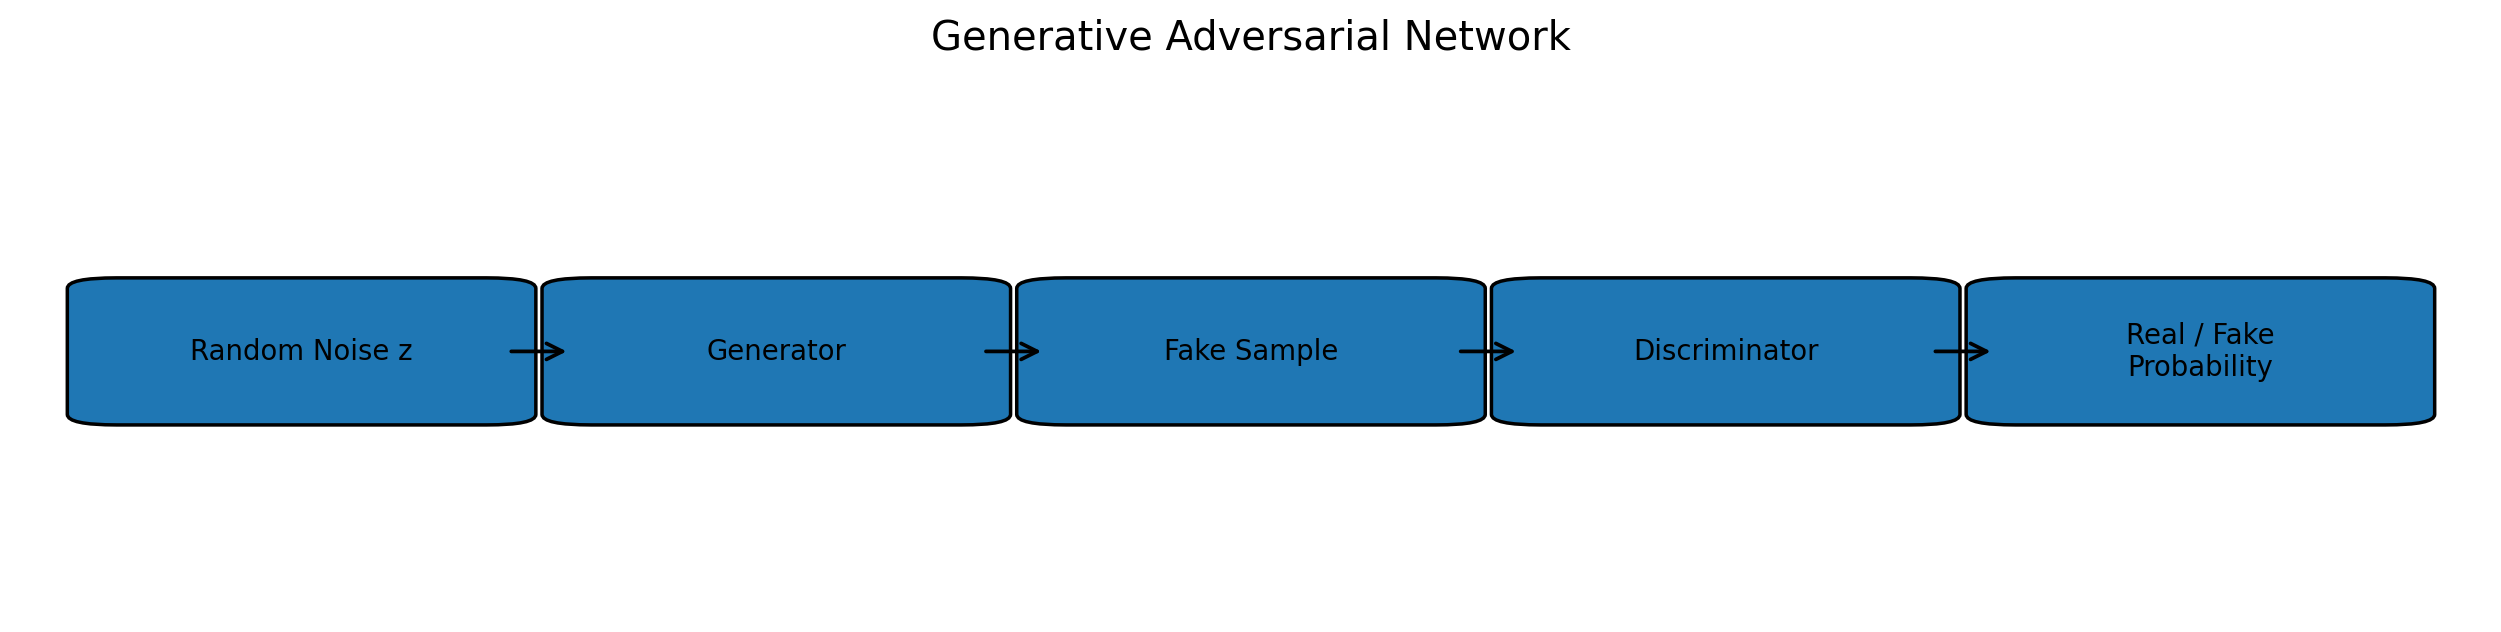

## 2. Learning Objectives

By the end of this notebook, you should be able to:

- explain the generator and discriminator roles,
- interpret the GAN minimax game,
- distinguish discriminator loss and generator loss,
- understand non-saturating generator training,
- construct a latent noise vector,
- build a Generator and Discriminator from scratch,
- implement alternating GAN training explicitly,
- visualize generated samples across training,
- inspect generator and discriminator loss behavior,
- understand instability, mode collapse, and equilibrium,
- explain how GANs differ from VAEs and diffusion models.

## 3. The Adversarial Learning Idea

The discriminator sees both:

```text
real data
generated data
```

and learns:

$$
D(x)
$$
which represents the estimated probability that \(x\) is real.

The generator takes random latent noise:

$$
z \sim p(z)
$$

and produces:

$$
G(z)
$$

The generator wants \(D(G(z))\) to behave as if the generated sample were real.

## 4. The Original Minimax Objective

The classic GAN objective is:

$$
\min_G \max_D
\;
\mathbb{E}_{x \sim p_{data}}
[\log D(x)]
+
\mathbb{E}_{z \sim p(z)}
[\log(1-D(G(z)))]
$$

Interpretation:

- the discriminator maximizes correct discrimination,
- the generator tries to make generated samples difficult to distinguish from real data.

## 5. A Simple Probability Example

Suppose the discriminator outputs:

```text
D(real image) = 0.92
D(fake image) = 0.18
```

Then the discriminator is currently doing well.

If later:

```text
D(fake image) = 0.75
```

the generator has become much more convincing.

Importantly, GAN training is a **dynamic game**. A low generator loss does not automatically mean the entire model is good.

## 6. Non-Saturating Generator Loss

In practice, the generator is commonly trained to maximize:

$$
\log D(G(z))
$$

rather than directly minimizing:

$$
\log(1-D(G(z)))
$$

This produces stronger gradients early in training.

With binary cross-entropy, we can implement this by pretending generated samples should have the target label:

```text
real label = 1
```

when updating the generator.

## 7. Imports and Reproducibility

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision import transforms

torch.manual_seed(42)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:")
print(device)

Device:
cpu


## 8. Load MNIST

To keep the focus on adversarial training, we use MNIST again. This also makes it easier to compare VAE and GAN outputs on the same basic data domain.

In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        (0.5,),
        (0.5,)
    )
])

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

print("Training samples:")
print(len(train_dataset))

100%|██████████| 9.91M/9.91M [00:00<00:00, 39.3MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 936kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 7.44MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 12.2MB/s]

Training samples:
60000


In [3]:
image, label = train_dataset[0]

print("Image shape:")
print(image.shape)

print()

print("Minimum normalized pixel value:")
print(image.min().item())

print()

print("Maximum normalized pixel value:")
print(image.max().item())

print()

print("Label:")
print(label)

Image shape:
torch.Size([1, 28, 28])

Minimum normalized pixel value:
-1.0

Maximum normalized pixel value:
1.0

Label:
5


Because the Generator will use a `tanh` output, the real images are normalized approximately to:

\[
[-1, 1]
\]

## 9. Create the DataLoader

In [4]:
batch_size = 128

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

print("Number of batches:")
print(len(train_loader))

Number of batches:
469


## 10. Latent Noise

The Generator does not receive an image.

It receives a random latent vector:

\[
z \sim \mathcal{N}(0,I)
\]

The Generator learns to transform this simple random distribution into the complex image distribution.

In [5]:
latent_dimension = 100

example_noise = torch.randn(
    4,
    latent_dimension
)

print("Noise shape:")
print(example_noise.shape)

print()

print("First ten values of the first noise vector:")
print(example_noise[0, :10])

Noise shape:
torch.Size([4, 100])

First ten values of the first noise vector:
tensor([ 1.9269,  1.4873,  0.9007, -2.1055,  0.6784, -1.2345, -0.0431, -1.6047,
        -0.7521,  1.6487])


## 11. Build the Generator

The Generator maps:

```text
100-dimensional noise
        ↓
hidden representations
        ↓
784 image values
        ↓
28 × 28 image
```

In [6]:
class Generator(nn.Module):

    def __init__(
        self,
        latent_dimension
    ):
        super().__init__()

        self.layer_1 = nn.Linear(
            latent_dimension,
            256
        )

        self.layer_2 = nn.Linear(
            256,
            512
        )

        self.layer_3 = nn.Linear(
            512,
            784
        )

        self.activation = nn.LeakyReLU(
            0.2
        )

        self.output_activation = nn.Tanh()


    def forward(self, z):

        x = self.layer_1(z)

        x = self.activation(x)

        x = self.layer_2(x)

        x = self.activation(x)

        x = self.layer_3(x)

        x = self.output_activation(x)

        return x

## 12. Build the Discriminator

The Discriminator receives a flattened image and returns one probability.

In [7]:
class Discriminator(nn.Module):

    def __init__(self):
        super().__init__()

        self.layer_1 = nn.Linear(
            784,
            512
        )

        self.layer_2 = nn.Linear(
            512,
            256
        )

        self.layer_3 = nn.Linear(
            256,
            1
        )

        self.activation = nn.LeakyReLU(
            0.2
        )

        self.output_activation = nn.Sigmoid()


    def forward(self, x):

        x = self.layer_1(x)

        x = self.activation(x)

        x = self.layer_2(x)

        x = self.activation(x)

        x = self.layer_3(x)

        probability = self.output_activation(x)

        return probability

## 13. Instantiate and Inspect Both Networks

In [8]:
generator = Generator(
    latent_dimension=latent_dimension
)

discriminator = Discriminator()

generator = generator.to(device)

discriminator = discriminator.to(device)

print("Generator:")
print(generator)

print()

print("Discriminator:")
print(discriminator)

Generator:
Generator(
  (layer_1): Linear(in_features=100, out_features=256, bias=True)
  (layer_2): Linear(in_features=256, out_features=512, bias=True)
  (layer_3): Linear(in_features=512, out_features=784, bias=True)
  (activation): LeakyReLU(negative_slope=0.2)
  (output_activation): Tanh()
)

Discriminator:
Discriminator(
  (layer_1): Linear(in_features=784, out_features=512, bias=True)
  (layer_2): Linear(in_features=512, out_features=256, bias=True)
  (layer_3): Linear(in_features=256, out_features=1, bias=True)
  (activation): LeakyReLU(negative_slope=0.2)
  (output_activation): Sigmoid()
)


In [9]:
generator_parameters = 0

for parameter in generator.parameters():
    generator_parameters = (
        generator_parameters
        + parameter.numel()
    )

discriminator_parameters = 0

for parameter in discriminator.parameters():
    discriminator_parameters = (
        discriminator_parameters
        + parameter.numel()
    )

print("Generator parameters:")
print(generator_parameters)

print()

print("Discriminator parameters:")
print(discriminator_parameters)

Generator parameters:
559632

Discriminator parameters:
533505


## 14. Follow Noise Through the Untrained Generator

In [10]:
noise = torch.randn(
    8,
    latent_dimension,
    device=device
)

with torch.no_grad():

    fake_images = generator(
        noise
    )

print("Generated flattened shape:")
print(fake_images.shape)

Generated flattened shape:
torch.Size([8, 784])


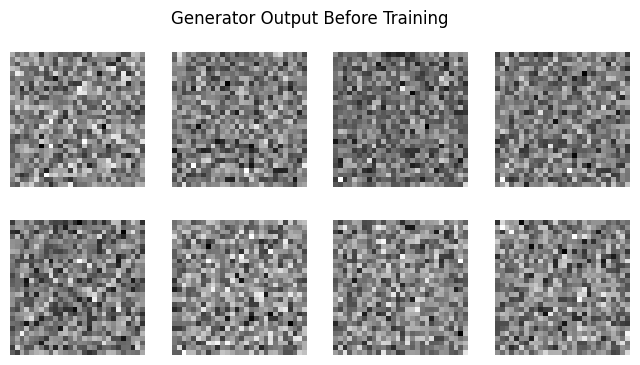

In [11]:
fake_images_display = fake_images.view(
    -1,
    1,
    28,
    28
)

fake_images_display = fake_images_display.cpu()

fake_images_display = (
    fake_images_display + 1.0
) / 2.0

plt.figure(figsize=(8, 4))

for index in range(8):

    plt.subplot(
        2,
        4,
        index + 1
    )

    plt.imshow(
        fake_images_display[index].squeeze(),
        cmap="gray"
    )

    plt.axis("off")

plt.suptitle(
    "Generator Output Before Training"
)

plt.show()

Before training, the generated images are essentially structured noise because the Generator has not learned the MNIST distribution.

## 15. Define Losses and Optimizers

The Discriminator and Generator have separate optimizers because they are updated for different objectives.

In [12]:
criterion = nn.BCELoss()

learning_rate = 0.0002

generator_optimizer = torch.optim.Adam(
    generator.parameters(),
    lr=learning_rate,
    betas=(0.5, 0.999)
)

discriminator_optimizer = torch.optim.Adam(
    discriminator.parameters(),
    lr=learning_rate,
    betas=(0.5, 0.999)
)

print("Loss:")
print(criterion)

print()

print("Learning rate:")
print(learning_rate)

Loss:
BCELoss()

Learning rate:
0.0002


## 16. One Discriminator Update Step

For each batch, the discriminator first learns from:

1. real images labeled as real,
2. generated images labeled as fake.

Generated samples are detached during this discriminator update because we do not want the generator to change yet.

## 17. One Generator Update Step

Next, new generated samples are passed through the discriminator.

The Generator is updated using **real labels** for its fake samples:

```text
target = 1
```

because the Generator's objective is to make the Discriminator believe the generated samples are real.

## 18. Train the GAN

GAN loss curves are not interpreted in exactly the same way as ordinary supervised learning curves. The two networks are competing and continually changing each other's training environment.

In [13]:
number_of_epochs = 20

generator_losses = []
discriminator_losses = []

fixed_noise = torch.randn(
    16,
    latent_dimension,
    device=device
)

In [14]:
for epoch in range(number_of_epochs):

    epoch_generator_loss = 0.0
    epoch_discriminator_loss = 0.0

    number_of_batches = 0

    for real_images, labels in train_loader:

        real_images = real_images.to(device)

        real_images = real_images.view(
            real_images.size(0),
            -1
        )

        current_batch_size = real_images.size(0)

        real_targets = torch.ones(
            current_batch_size,
            1,
            device=device
        )

        fake_targets = torch.zeros(
            current_batch_size,
            1,
            device=device
        )


        # ---------------------------------
        # Train the Discriminator.
        # ---------------------------------

        discriminator_optimizer.zero_grad()

        real_predictions = discriminator(
            real_images
        )

        real_loss = criterion(
            real_predictions,
            real_targets
        )

        noise = torch.randn(
            current_batch_size,
            latent_dimension,
            device=device
        )

        fake_images = generator(
            noise
        )

        fake_predictions = discriminator(
            fake_images.detach()
        )

        fake_loss = criterion(
            fake_predictions,
            fake_targets
        )

        discriminator_loss = (
            real_loss
            + fake_loss
        )

        discriminator_loss.backward()

        discriminator_optimizer.step()


        # ---------------------------------
        # Train the Generator.
        # ---------------------------------

        generator_optimizer.zero_grad()

        generated_predictions = discriminator(
            fake_images
        )

        generator_loss = criterion(
            generated_predictions,
            real_targets
        )

        generator_loss.backward()

        generator_optimizer.step()


        epoch_discriminator_loss = (
            epoch_discriminator_loss
            + discriminator_loss.item()
        )

        epoch_generator_loss = (
            epoch_generator_loss
            + generator_loss.item()
        )

        number_of_batches = (
            number_of_batches + 1
        )


    average_discriminator_loss = (
        epoch_discriminator_loss
        / number_of_batches
    )

    average_generator_loss = (
        epoch_generator_loss
        / number_of_batches
    )

    discriminator_losses.append(
        average_discriminator_loss
    )

    generator_losses.append(
        average_generator_loss
    )

    print(
        "Epoch:",
        epoch + 1,
        "| D Loss:",
        round(average_discriminator_loss, 4),
        "| G Loss:",
        round(average_generator_loss, 4)
    )

Epoch: 1 | D Loss: 0.9704 | G Loss: 1.2783
Epoch: 2 | D Loss: 0.7081 | G Loss: 2.2486
Epoch: 3 | D Loss: 0.6861 | G Loss: 2.2939
Epoch: 4 | D Loss: 0.6299 | G Loss: 2.5571
Epoch: 5 | D Loss: 0.6683 | G Loss: 2.5131
Epoch: 6 | D Loss: 0.6127 | G Loss: 2.592
Epoch: 7 | D Loss: 0.6283 | G Loss: 2.7156
Epoch: 8 | D Loss: 0.586 | G Loss: 2.8878
Epoch: 9 | D Loss: 0.5156 | G Loss: 3.0437
Epoch: 10 | D Loss: 0.5022 | G Loss: 3.2333
Epoch: 11 | D Loss: 0.5238 | G Loss: 2.9367
Epoch: 12 | D Loss: 0.5508 | G Loss: 2.7407
Epoch: 13 | D Loss: 0.5762 | G Loss: 2.6573
Epoch: 14 | D Loss: 0.5967 | G Loss: 2.5749
Epoch: 15 | D Loss: 0.6415 | G Loss: 2.4256
Epoch: 16 | D Loss: 0.7144 | G Loss: 2.1601
Epoch: 17 | D Loss: 0.8056 | G Loss: 1.905
Epoch: 18 | D Loss: 0.8441 | G Loss: 1.7737
Epoch: 19 | D Loss: 0.9065 | G Loss: 1.6064
Epoch: 20 | D Loss: 0.9476 | G Loss: 1.5136


## 19. Plot Generator and Discriminator Loss

Do not interpret "smaller is always better" here.

Healthy adversarial learning often involves oscillation because one network improves in response to the other.

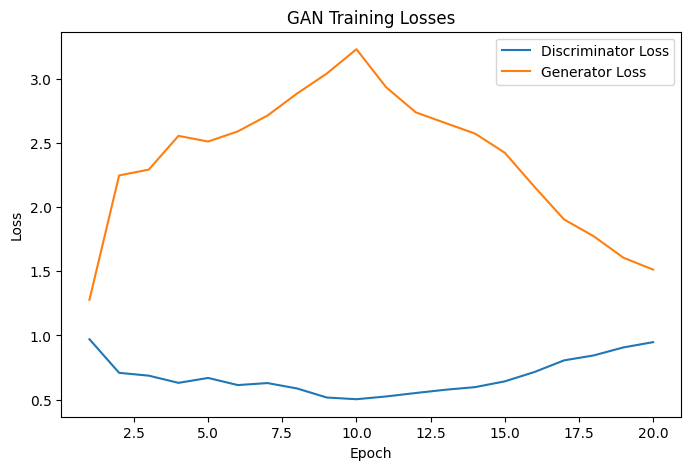

In [15]:
epochs = range(
    1,
    number_of_epochs + 1
)

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    discriminator_losses,
    label="Discriminator Loss"
)

plt.plot(
    epochs,
    generator_losses,
    label="Generator Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("GAN Training Losses")
plt.legend()

plt.show()

## 20. Generate Images After Training

We reuse a fixed latent-noise set so the change is attributable to learning rather than different random inputs.

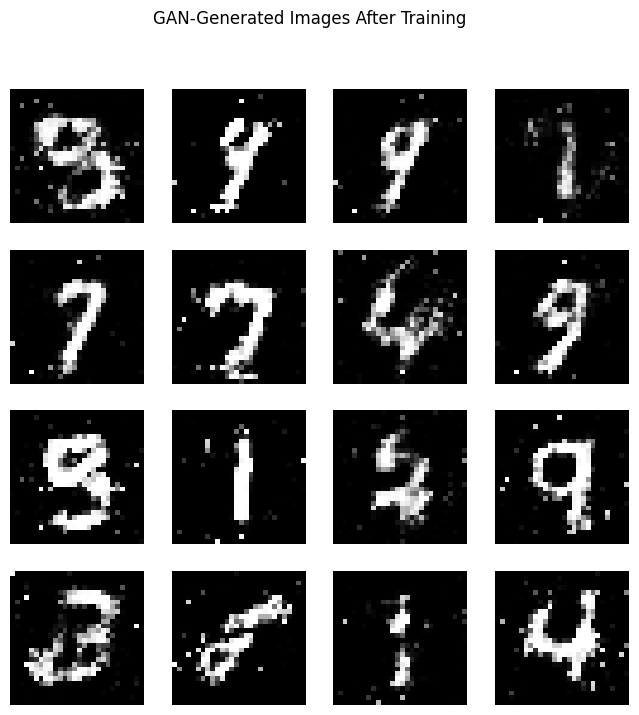

In [16]:
generator.eval()

with torch.no_grad():

    generated_images = generator(
        fixed_noise
    )

generated_images = generated_images.view(
    -1,
    1,
    28,
    28
)

generated_images = generated_images.cpu()

generated_images = (
    generated_images + 1.0
) / 2.0

plt.figure(figsize=(8, 8))

for index in range(16):

    plt.subplot(
        4,
        4,
        index + 1
    )

    plt.imshow(
        generated_images[index].squeeze(),
        cmap="gray"
    )

    plt.axis("off")

plt.suptitle(
    "GAN-Generated Images After Training"
)

plt.show()

## 21. Latent Interpolation in a GAN

A Generator maps points in latent space to images.

Interpolating between two latent vectors helps us observe whether the Generator has learned a smooth mapping.

In [17]:
z_start = torch.randn(
    1,
    latent_dimension,
    device=device
)

z_end = torch.randn(
    1,
    latent_dimension,
    device=device
)

number_of_steps = 10

interpolation_weights = torch.linspace(
    0.0,
    1.0,
    number_of_steps,
    device=device
)

interpolated_z = []

for weight in interpolation_weights:

    z = (
        (1.0 - weight) * z_start
        + weight * z_end
    )

    interpolated_z.append(z)

interpolated_z = torch.cat(
    interpolated_z,
    dim=0
)

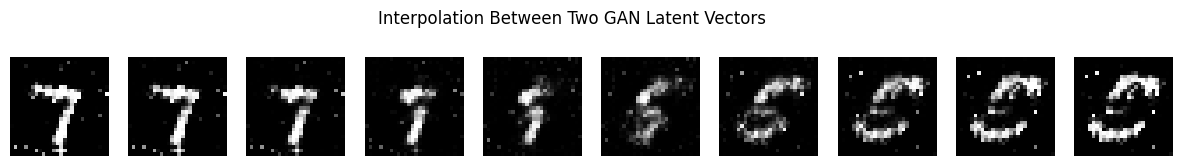

In [18]:
with torch.no_grad():

    interpolated_images = generator(
        interpolated_z
    )

interpolated_images = interpolated_images.view(
    -1,
    1,
    28,
    28
)

interpolated_images = interpolated_images.cpu()

interpolated_images = (
    interpolated_images + 1.0
) / 2.0

plt.figure(figsize=(15, 2))

for index in range(number_of_steps):

    plt.subplot(
        1,
        number_of_steps,
        index + 1
    )

    plt.imshow(
        interpolated_images[index].squeeze(),
        cmap="gray"
    )

    plt.axis("off")

plt.suptitle(
    "Interpolation Between Two GAN Latent Vectors"
)

plt.show()

## 22. Deeper Understanding: What Is Equilibrium?

The ideal theoretical picture is:

$$
p_g(x) = p_{data}(x)
$$

If generated and real distributions become identical, the Discriminator can no longer reliably tell them apart.

Its output approaches:

$$
D(x) \approx 0.5
$$

for both real and generated samples.

In practical GAN training, reaching a stable equilibrium is difficult.

## 23. Failure Mode: Mode Collapse

A Generator may discover that a small number of outputs repeatedly fool the Discriminator.

Instead of learning the full data distribution, it generates only a limited subset.

For example, an MNIST GAN might produce many convincing images but only a few digit styles.

This is called **mode collapse**.

## 24. Other Common GAN Problems

- unstable training,
- vanishing generator gradients,
- discriminator overpowering the generator,
- sensitivity to architecture and hyperparameters,
- difficulty evaluating generated-image quality,
- mode collapse.

These challenges motivated many GAN variants such as:

- DCGAN,
- WGAN,
- WGAN-GP,
- conditional GANs,
- StyleGAN.

## 25. Extension: From MLP GAN to DCGAN

The current notebook uses fully connected networks to keep the adversarial mechanics transparent.

For natural images, convolutional generators and discriminators are usually more appropriate.

A DCGAN-style progression is:

```text
latent vector
    ↓
reshape
    ↓
transposed convolution
    ↓
upsampling feature maps
    ↓
generated image
```

and the discriminator uses convolutional downsampling.

This connects directly to the convolution and transposed-convolution knowledge developed earlier in the Deep Learning portfolio.

## 26. VAE vs GAN

### VAE

- explicit probabilistic latent model,
- reconstruction-based training,
- usually stable training,
- often smoother but blurrier outputs.

### GAN

- adversarial training,
- no reconstruction requirement,
- can generate sharper images,
- harder and less stable to train.

The next generative family avoids the generator-discriminator competition and instead learns a **progressive denoising process**.

## 27. Connection to the Next Notebook

Diffusion models begin with real data and gradually add noise.

A neural network then learns how to reverse that process.

The central question becomes:

> Can generation be learned as repeated denoising rather than direct decoding or adversarial competition?

## 28. Key Takeaways

- GANs consist of a Generator and a Discriminator.
- The Generator transforms random latent noise into synthetic samples.
- The Discriminator learns to distinguish real and generated samples.
- Training alternates between the two objectives.
- GAN loss curves reflect a competitive game rather than a single supervised objective.
- GANs can produce sharp outputs but are susceptible to instability and mode collapse.
- The latent space can be explored through fixed-noise tracking and interpolation.